In [1]:
import pandas as pd
from sklearn import tree

In [2]:
df = pd.read_csv("TeoMeWhy/data/Dados Comunidade (respostas) - dados.csv")
df.head()

,Carimbo de data/hora,Como conheceu o Téo Me Why?,Quantos cursos acompanhou do Téo Me Why?,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,Estado que mora atualmente,Área de Formação,Tempo que atua na área de dados,Posição da cadeira (senioridade),Você se considera uma pessoa feliz?
0,12/06/2025 10:59:27,LinkedIn,0,Sim,Não,Sim,Sim,Sim,Não,34,MG,Exatas,Mais de 4 anos,Sênior,Sim
1,12/06/2025 10:59:34,Twitch,Mais que 3,Sim,Sim,Sim,Não,Não,Sim,26,MG,Exatas,Não atuo,Iniciante,Sim
2,12/06/2025 10:59:36,YouTube,Mais que 3,Sim,Sim,Sim,Sim,Sim,Sim,39,SC,Exatas,De 1 ano a 2 anos,Júnior,Sim
3,12/06/2025 10:59:37,YouTube,Mais que 3,Sim,Sim,Sim,Sim,Sim,Não,27,SP,Exatas,Mais de 4 anos,Pleno,Sim
4,12/06/2025 10:59:41,Twitch,2,Sim,Sim,Sim,Sim,Não,Não,29,CE,Exatas,De 1 ano a 2 anos,Pleno,Sim


In [3]:
df = df.replace({"Sim":1, "Não":0})
df.head()

,Carimbo de data/hora,Como conheceu o Téo Me Why?,Quantos cursos acompanhou do Téo Me Why?,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,Estado que mora atualmente,Área de Formação,Tempo que atua na área de dados,Posição da cadeira (senioridade),Você se considera uma pessoa feliz?
0,12/06/2025 10:59:27,LinkedIn,0,1,0,1,1,1,0,34,MG,Exatas,Mais de 4 anos,Sênior,1
1,12/06/2025 10:59:34,Twitch,Mais que 3,1,1,1,0,0,1,26,MG,Exatas,Não atuo,Iniciante,1
2,12/06/2025 10:59:36,YouTube,Mais que 3,1,1,1,1,1,1,39,SC,Exatas,De 1 ano a 2 anos,Júnior,1
3,12/06/2025 10:59:37,YouTube,Mais que 3,1,1,1,1,1,0,27,SP,Exatas,Mais de 4 anos,Pleno,1
4,12/06/2025 10:59:41,Twitch,2,1,1,1,1,0,0,29,CE,Exatas,De 1 ano a 2 anos,Pleno,1


In [4]:
num_vars = [
    "Curte games?",
    "Curte futebol?",
    "Curte livros?",
    "Curte jogos de tabuleiro?",
    "Curte jogos de fórmula 1?",
    "Curte jogos de MMA?",
    "Idade"
]
dummy_vars =[
    "Como conheceu o Téo Me Why?",
    "Quantos cursos acompanhou do Téo Me Why?",
    "Área de Formação",
    "Tempo que atua na área de dados",
    "Posição da cadeira (senioridade)" 
]

df_analise = pd.get_dummies(df[dummy_vars]).astype(int)
df_analise[num_vars] = df[num_vars].copy()
df_analise['pessoa feliz'] = df['Você se considera uma pessoa feliz?'].copy()
df_analise.head()

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,pessoa feliz
0,0,0,1,0,0,0,0,1,0,0,...,0,1,1,0,1,1,1,0,34,1
1,0,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,0,0,1,26,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,1,1,39,1
3,0,0,0,0,0,0,1,0,0,0,...,1,0,1,1,1,1,1,0,27,1
4,0,0,0,0,1,0,0,0,0,1,...,1,0,1,1,1,1,0,0,29,1


In [5]:
features = df_analise.columns[:-1].tolist()
#print(features)
X = df_analise[features]
y = df_analise['pessoa feliz'].astype(int)
print(y.head())
print('formato de X: ',X.shape)
print('formato de y: ',y.shape)


0    1
1    1
2    1
3    1
4    1
Name: pessoa feliz, dtype: int64
formato de X:  (182, 37)
formato de y:  (182,)


In [6]:


arvore = tree.DecisionTreeClassifier(random_state=42,min_samples_leaf=5)

arvore.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [7]:
arvore_predict= arvore.predict(X)
print(arvore_predict)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1
 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1
 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 0 0 0 1]


In [25]:
df_predict = df_analise[['pessoa feliz']].copy()
df_predict['predict_arvore'] = arvore_predict


df_predict['proba_arvore'] = arvore.predict_proba(X)[:,1]
print(df_predict)

    pessoa feliz  predict_arvore  proba_arvore
0              1               1      1.000000
1              1               1      0.600000
2              1               1      0.857143
3              1               1      0.857143
4              1               1      1.000000
..           ...             ...           ...
177            1               1      0.800000
178            1               0      0.428571
179            0               0      0.500000
180            0               0      0.500000
181            1               1      1.000000

[182 rows x 3 columns]


In [9]:
# acurácia - porém não é suficiente
(df_predict['pessoa feliz'] == df_predict['predict_arvore']).mean()


np.float64(0.8516483516483516)

In [10]:
# matriz de confusao "na mão"

pd.crosstab(df_predict['pessoa feliz'], df_predict['predict_arvore'])

predict_arvore,0,1
pessoa feliz,,
0,22,13
1,14,133


In [24]:
total_0 = (df_predict['pessoa feliz'] == 0).sum()

total_1 = (df_predict['pessoa feliz'] == 1).sum()
print('total de uns no df: ',total_1,'\ntotal de zeros no df: ',total_0)

print(type(df_predict['pessoa feliz']))
print(type(df_predict['predict_arvore']))

total de uns no df:  147 
total de zeros no df:  35
<class 'pandas.Series'>
<class 'pandas.Series'>


In [12]:
df_predict.to_csv("TeoMeWhy/data/predict.csv", sep=';', index=False)

### Precisão
> Se eu disser que uma pessoa é feliz eu tenho quase [valor_prec] de ser feliz

$precisao = VP/(VP + FP)$

### Acurácia
$acuracia = (VN + VP) / Total$

### Recall ou Sensibilidade
> De todo mundo que é feliz, quantos eu estou dizendo que de fato são felizes? *questões críticas*

$recall = VP / FN + VP$

### Especificidade
> O quanto dos negativos estou capturando -- contrário do recall

$especificidade = VN/(VN+FP)$

### Área sob a Curva ROC (AUC)
> Sensibilidade (recall) x Especificidade

recall = quanto estou capturando da classe 1 

especificidade = quanto estou capturando da classe 0

recall e especificidade em diferentes pontes de corte

- é um gráfico que avalia o desempenho de um modelo de classificação binária ao traçar a relação entre duas métricas em diferentes pontos de corte (thresholds): {recall e especificidade em diferentes pontes de corte}

**Eixo Y** (Sensibilidade ou Recall): Representa a taxa de verdadeiros positivos. Mostra a proporção de casos positivos reais que o modelo conseguiu identificar corretamente.

**Eixo X** (1 - Especificidade): Representa a taxa de falsos positivos. Mostra a proporção de casos negativos que o modelo classificou erroneamente como positivos.


In [26]:
from sklearn import metrics

#acc_arvore = metrics.accuracy_score(df_predict['pessoa feliz'], df_predict['predict_arvore'])
#print(acc_arvore)
precisao_arvore = metrics.precision_score(df_predict['pessoa feliz'], df_predict['predict_arvore'])
recall_arvore = metrics.recall_score(df_predict['pessoa feliz'], df_predict['predict_arvore'])
roc = metrics.roc_curve(df_predict['pessoa feliz'], df_predict['proba_arvore'])

ValueError: Classification metrics can't handle a mix of unknown and binary targets

In [27]:
from sklearn import metrics

y_true = df_predict['pessoa feliz'].astype(int)
y_pred = df_predict['predict_arvore'].astype(int)
y_prob = df_predict['proba_arvore']

print("Accuracy:", metrics.accuracy_score(y_true, y_pred))
print("Precision:", metrics.precision_score(y_true, y_pred))
print("Recall:", metrics.recall_score(y_true, y_pred))
print("F1:", metrics.f1_score(y_true, y_pred))
print("ROC AUC:", metrics.roc_auc_score(y_true, y_prob))

Accuracy: 0.8516483516483516
Precision: 0.910958904109589
Recall: 0.9047619047619048
F1: 0.9078498293515358
ROC AUC: 0.9121477162293488


(array([  8.,   9.,   7.,  12.,  20.,   0.,   8.,  10.,   7., 101.]),
 array([0.25 , 0.325, 0.4  , 0.475, 0.55 , 0.625, 0.7  , 0.775, 0.85 ,
        0.925, 1.   ]),
 <BarContainer object of 10 artists>)

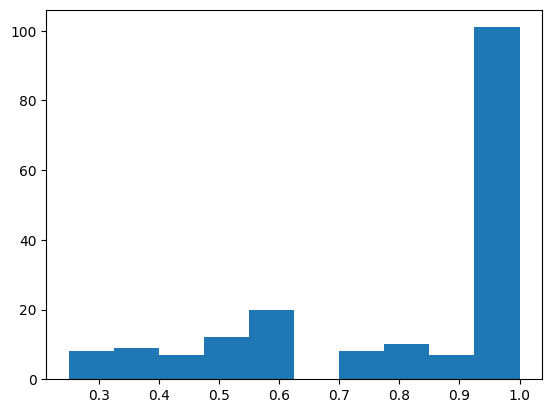

In [28]:
import matplotlib.pyplot as plt
plt.hist(df_predict['proba_arvore'])